# 14 — Proper Stacking (4-Model Version)

## What this notebook does
- Builds a **time-series-safe stacked ensemble with leakage-safe grid search for every base learner** using **out-of-fold (OOF) probabilities**.
- Compares **two meta learners** on the same OOF meta-features:
  - `Meta_LogReg`
  - `Meta_HistGB`
## Base learners
- CatBoost
- LightGBM
- Logistic Regression
- ExtraTrees

- Uses **4 rolling outer folds** on the development window and **4-fold inner grid search** for each base learner.
- Re-tunes each base learner on the full development set before final test scoring.


### Main metrics reported
The notebook computes several metrics internally, but the compact saved summaries focus on:
- `macro_recall`
- `recall_2`
- `precision_2`
- `ap_class2`
- `macro_map`
- `prob_rmse_macro`

In [1]:

from pathlib import Path
import json
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.base import clone
from sklearn.model_selection import ParameterGrid

from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    precision_score,
    average_precision_score,
    mean_squared_error,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier , ExtraTreesClassifier
from sklearn.inspection import permutation_importance

try:
    from catboost import CatBoostClassifier
except Exception as e:
    raise RuntimeError(
        "CatBoost is required for this notebook. Install it first with: pip install catboost\n"
        f"Original error: {e}"
    )

try:
    from lightgbm import LGBMClassifier
except Exception as e:
    raise RuntimeError(
        "LightGBM is required for this notebook. Install it first with: pip install lightgbm\n"
        f"Original error: {e}"
    )

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SUPERVISED_PATH = DATA_DIR / "supervised_hood_3h_multiclass.csv"

OUT_CV_SUMMARY = MODEL_DIR / "stacking_4model_cv_summary.csv"
OUT_FINAL_RESULTS = MODEL_DIR / "stacking_4model_final_results.csv"
OUT_META_IMPORTANCE = MODEL_DIR / "stacking_4model_meta_importance.csv"
OUT_META_COMPARE = MODEL_DIR / "stacking_4model_meta_compare.csv"
OUT_DASHBOARD_FEATURES = MODEL_DIR / "stacking_4model_dashboard_features.csv"
OUT_DASHBOARD_BUNDLE = MODEL_DIR / "stacking_4model_dashboard_bundle.pkl"
OUT_MANIFEST = MODEL_DIR / "stacking_4model_manifest.json"
OUT_BASE_TUNING = MODEL_DIR / "stacking_4model_base_tuning.csv"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Hold out the final test window.
TEST_START = pd.Timestamp("2025-07-01 00:00:00")

# Time-series CV setup:
# We now use exact 4-fold rolling CV on development data, plus 4-fold
# inner time-series grid search for each base learner within each outer fold.
OUTER_N_SPLITS = 4
INNER_N_SPLITS = 4

# Lightweight model settings chosen to run on a MacBook Air more easily.
THREADS = min(6, os.cpu_count() or 4)
CB_ITER = 220
LGBM_EST = 220
LOGREG_MAX_ITER = 1200
HISTGB_EST = 220
EXTRATREES_EST = 140

print("Input dataset:", SUPERVISED_PATH)
print("Model output folder:", MODEL_DIR)


Input dataset: ../data/processed/supervised_hood_3h_multiclass.csv
Model output folder: ../models


In [2]:

# ------------------------------------------------------------
# Load the supervised panel dataset
# ------------------------------------------------------------
df = pd.read_csv(SUPERVISED_PATH, low_memory=False)

if "time_3h" not in df.columns:
    raise ValueError("Expected a 'time_3h' column in supervised_hood_3h_multiclass.csv")
if "y_class" not in df.columns:
    raise ValueError("Expected a 'y_class' target column in supervised_hood_3h_multiclass.csv")

df["time_3h"] = pd.to_datetime(df["time_3h"], errors="coerce")
df = df.loc[df["time_3h"].notna()].copy()

# Keep neighbourhood codes as strings for stable categorical handling.
if "HOOD_158_CODE" in df.columns:
    df["HOOD_158_CODE"] = df["HOOD_158_CODE"].astype(str).str.zfill(3)

df["y_class"] = pd.to_numeric(df["y_class"], errors="coerce")
df = df.loc[df["y_class"].notna()].copy()
df["y_class"] = df["y_class"].astype("int8")

sort_cols = ["time_3h"] + (["HOOD_158_CODE"] if "HOOD_158_CODE" in df.columns else [])
df = df.sort_values(sort_cols).reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["time_3h"].min(), "to", df["time_3h"].max())
print("\nClass distribution (full dataset):")
print(df["y_class"].value_counts(normalize=True).sort_index().round(4))
display(df.head())


Shape: (1383922, 50)
Date range: 2023-01-02 00:00:00 to 2025-12-31 18:00:00

Class distribution (full dataset):
y_class
0    0.8930
1    0.0927
2    0.0143
Name: proportion, dtype: float64


,HOOD_158_CODE,time_3h,collisions,injury_collisions,ftr_collisions,pd_collisions,pedestrian_collisions,bicycle_collisions,pressure_sea,wind_speed,...,visibility_lag_1,rain_lag_1,snow_lag_1,snow_on_ground_lag_1,wind_speed_lag_1,relative_humidity_lag_1,pressure_sea_lag_1,cloud_cover_8_lag_1,y_count_next,y_class
0,001,2023-01-02,0,0,0,0,0,0,101.643,8.0,...,9700.0,8.4,0.0,0.0,11.333,100.0,101.577,7.333,0.0,0
1,002,2023-01-02,0,0,0,0,0,0,101.643,8.0,...,9700.0,8.4,0.0,0.0,11.333,100.0,101.577,7.333,0.0,0
2,003,2023-01-02,0,0,0,0,0,0,101.643,8.0,...,9700.0,8.4,0.0,0.0,11.333,100.0,101.577,7.333,0.0,0
3,004,2023-01-02,0,0,0,0,0,0,101.643,8.0,...,9700.0,8.4,0.0,0.0,11.333,100.0,101.577,7.333,1.0,1
4,005,2023-01-02,0,0,0,0,0,0,101.643,8.0,...,9700.0,8.4,0.0,0.0,11.333,100.0,101.577,7.333,0.0,0


In [3]:

# ------------------------------------------------------------
# Split into development and final test sets
# ------------------------------------------------------------
dev_mask = df["time_3h"] < TEST_START
test_mask = ~dev_mask

y = df["y_class"].copy()
drop_targets = [c for c in ["y_class", "y_count_next"] if c in df.columns]
X = df.drop(columns=drop_targets, errors="ignore").copy()

time_all = df["time_3h"].copy()
X = X.drop(columns=["time_3h"], errors="ignore")

X_dev = X.loc[dev_mask].reset_index(drop=True).copy()
y_dev = y.loc[dev_mask].reset_index(drop=True).copy()
time_dev = time_all.loc[dev_mask].reset_index(drop=True).copy()

X_test = X.loc[test_mask].reset_index(drop=True).copy()
y_test = y.loc[test_mask].reset_index(drop=True).copy()
time_test = time_all.loc[test_mask].reset_index(drop=True).copy()

if len(X_dev) == 0 or len(X_test) == 0:
    raise ValueError("Development or test split is empty. Check TEST_START against your data range.")

print("Dev shape:", X_dev.shape, "| Test shape:", X_test.shape)
print("Dev range:", time_dev.min(), "to", time_dev.max())
print("Test range:", time_test.min(), "to", time_test.max())
print("\nDev class distribution:")
print(y_dev.value_counts(normalize=True).sort_index().round(4))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(4))


Dev shape: (1151504, 47) | Test shape: (232418, 47)
Dev range: 2023-01-02 00:00:00 to 2025-06-30 21:00:00
Test range: 2025-07-01 00:00:00 to 2025-12-31 18:00:00

Dev class distribution:
y_class
0    0.8927
1    0.0930
2    0.0143
Name: proportion, dtype: float64

Test class distribution:
y_class
0    0.8942
1    0.0912
2    0.0147
Name: proportion, dtype: float64


In [4]:

# ------------------------------------------------------------
# Helper functions: preprocessing, models, folds, tuning, metrics, plots
# ------------------------------------------------------------
def make_ohe():
    """Create a OneHotEncoder that works across sklearn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

# Treat string/object columns as categorical. Also keep HOOD_158_CODE categorical.
cat_cols = [c for c in X_dev.columns if X_dev[c].dtype == "object"]
if "HOOD_158_CODE" in X_dev.columns and "HOOD_158_CODE" not in cat_cols:
    cat_cols.append("HOOD_158_CODE")

# Remove duplicates while preserving order.
cat_cols = list(dict.fromkeys(cat_cols))
num_cols = [c for c in X_dev.columns if c not in cat_cols]

for frame in [X_dev, X_test]:
    for c in cat_cols:
        frame[c] = frame[c].astype(str).fillna("missing")

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))
print("Total features used:", X_dev.shape[1])


def build_preprocessor(use_scaler_for_num=False):
    """
    Build a preprocessing pipeline for sklearn-style models.
    - Numeric: median imputation (+ optional scaling)
    - Categorical: mode imputation + one-hot encoding
    """
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if use_scaler_for_num:
        num_steps.append(("scaler", StandardScaler()))

    num_pipe = Pipeline(num_steps)
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_ohe()),
    ])

    return ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ], remainder="drop")


def get_catboost_class_weights(y_fit):
    class_counts = pd.Series(y_fit).value_counts().sort_index()
    weights = []
    for cls in [0, 1, 2]:
        count = max(1, int(class_counts.get(cls, 1)))
        weights.append(len(y_fit) / (3.0 * count))
    return weights


def build_logreg_pipe(params=None):
    params = params or {}
    return Pipeline([
        ("preprocess", build_preprocessor(use_scaler_for_num=True)),
        ("clf", LogisticRegression(
            max_iter=LOGREG_MAX_ITER,
            solver="lbfgs",
            multi_class="multinomial",
            class_weight="balanced",
            random_state=RANDOM_SEED,
            C=params.get("C", 1.0),
        )),
    ])


def build_lgbm_pipe(params=None):
    params = params or {}
    return Pipeline([
        ("preprocess", build_preprocessor(use_scaler_for_num=False)),
        ("clf", LGBMClassifier(
            objective="multiclass",
            num_class=3,
            n_estimators=params.get("n_estimators", LGBM_EST),
            learning_rate=params.get("learning_rate", 0.05),
            num_leaves=params.get("num_leaves", 31),
            min_child_samples=params.get("min_child_samples", 100),
            subsample=params.get("subsample", 0.8),
            colsample_bytree=params.get("colsample_bytree", 0.8),
            random_state=RANDOM_SEED,
            class_weight="balanced",
            n_jobs=THREADS,
            verbosity=-1,
        )),
    ])


def build_cb_model(y_fit, params=None):
    """
    CatBoost consumes raw columns directly. Class weights are computed from the
    current fitting sample so every fold remains leakage-safe and imbalance-aware.
    """
    params = params or {}
    return CatBoostClassifier(
        loss_function="MultiClass",
        iterations=params.get("iterations", CB_ITER),
        learning_rate=params.get("learning_rate", 0.05),
        depth=params.get("depth", 6),
        random_seed=RANDOM_SEED,
        verbose=False,
        thread_count=THREADS,
        class_weights=get_catboost_class_weights(y_fit),
    )


def build_extratrees_pipe(params=None):
    params = params or {}
    return Pipeline([
        ("preprocess", build_preprocessor(use_scaler_for_num=False)),
        ("clf", ExtraTreesClassifier(
            n_estimators=params.get("n_estimators", EXTRATREES_EST),
            max_depth=params.get("max_depth", 16),
            min_samples_leaf=params.get("min_samples_leaf", 2),
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_SEED,
            n_jobs=THREADS,
        )),
    ])


BASE_PARAM_GRIDS = {
    "CatBoost": {
        "depth": [5, 7],
        "learning_rate": [0.03, 0.05],
        "iterations": [180, 260],
    },
    "LightGBM": {
        "num_leaves": [31, 63],
        "learning_rate": [0.03, 0.05],
        "min_child_samples": [50, 100],
        "n_estimators": [180, 260],
    },
    "LogReg": {
        "C": [0.5, 1.0, 2.0, 4.0],
    },
    "ExtraTrees": {
        "n_estimators": [140, 220],
        "max_depth": [12, 16],
        "min_samples_leaf": [1, 2],
    },
}


TUNING_SORT_COLUMNS = ["macro_recall", "ap_class2", "macro_map", "recall_2", "prob_rmse_macro"]
TUNING_SORT_ASC = [False, False, False, False, True]


def rank_metric_table(df):
    return (
        df.sort_values(TUNING_SORT_COLUMNS, ascending=TUNING_SORT_ASC)
          .reset_index(drop=True)
    )


def make_time_folds(time_series, n_splits=OUTER_N_SPLITS):
    """
    Create exact rolling time-series folds.
    We split unique timestamps into n_splits + 1 contiguous chunks so that:
    - fold 1 trains on chunk 1 and validates on chunk 2
    - fold 2 trains on chunks 1-2 and validates on chunk 3
    - ...
    - fold n_splits trains on all previous chunks and validates on the next chunk
    This gives exactly `n_splits` validation folds.
    """
    unique_times = np.array(sorted(pd.Series(time_series).astype("datetime64[ns]").unique()))
    required_chunks = n_splits + 1
    if len(unique_times) < required_chunks:
        raise ValueError(
            f"Need at least {required_chunks} unique time points for {n_splits} rolling folds, got {len(unique_times)}."
        )

    chunks = np.array_split(unique_times, required_chunks)
    folds = []

    time_series = pd.Series(time_series)
    for val_chunk_idx in range(1, len(chunks)):
        train_times = np.concatenate(chunks[:val_chunk_idx])
        val_times = chunks[val_chunk_idx]
        tr_idx = np.where(time_series.isin(train_times).values)[0]
        va_idx = np.where(time_series.isin(val_times).values)[0]

        if len(tr_idx) == 0 or len(va_idx) == 0:
            continue
        folds.append((tr_idx, va_idx))

    if len(folds) != n_splits:
        raise ValueError(f"Expected {n_splits} folds, created {len(folds)} folds instead.")
    return folds


def eval_multiclass(y_true, y_pred, proba, name="model", split="cv"):
    """
    Compute the main evaluation metrics used across this project.
    """
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)
    proba_arr = np.asarray(proba)

    rec = recall_score(
        y_true_arr, y_pred_arr,
        labels=[0, 1, 2],
        average=None,
        zero_division=0,
    )
    macro_rec = float(np.mean(rec))

    prec2 = precision_score(
        (y_true_arr == 2).astype(int),
        (y_pred_arr == 2).astype(int),
        zero_division=0,
    )
    pred_class2_rate = float((y_pred_arr == 2).mean())

    ap_dict = {}
    ap_vals = []
    class_support = []

    for cls in [0, 1, 2]:
        y_true_bin = (y_true_arr == cls).astype(int)
        support = int(y_true_bin.sum())
        class_support.append(support)

        if support == 0:
            ap = np.nan
        else:
            ap = float(average_precision_score(y_true_bin, proba_arr[:, cls]))

        ap_dict[f"ap_class{cls}"] = ap
        if not np.isnan(ap):
            ap_vals.append(ap)

    macro_map = float(np.mean(ap_vals)) if len(ap_vals) else np.nan

    valid_pairs = [
        (ap_dict[f"ap_class{cls}"], class_support[cls])
        for cls in [0, 1, 2]
        if not np.isnan(ap_dict[f"ap_class{cls}"])
    ]
    if len(valid_pairs):
        weighted_map = float(
            np.average(
                [x[0] for x in valid_pairs],
                weights=[x[1] for x in valid_pairs],
            )
        )
    else:
        weighted_map = np.nan

    label_rmse = float(np.sqrt(mean_squared_error(y_true_arr, y_pred_arr)))

    y_onehot = np.zeros((len(y_true_arr), 3), dtype=float)
    y_onehot[np.arange(len(y_true_arr)), y_true_arr.astype(int)] = 1.0
    prob_rmse_macro = float(
        np.mean([
            np.sqrt(mean_squared_error(y_onehot[:, c], proba_arr[:, c]))
            for c in range(3)
        ])
    )

    row = {
        "split": split,
        "model": name,
        "macro_recall": macro_rec,
        "recall_0": float(rec[0]),
        "recall_1": float(rec[1]),
        "recall_2": float(rec[2]),
        "precision_2": float(prec2),
        "pred_class2_rate": pred_class2_rate,
        "macro_map": macro_map,
        "weighted_map": weighted_map,
        "label_rmse": label_rmse,
        "prob_rmse_macro": prob_rmse_macro,
    }
    row.update(ap_dict)
    return row


def plot_confusion(cm, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels([0, 1, 2])
    ax.set_yticklabels([0, 1, 2])
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def fit_predict_base_model(model_name, params, X_fit, y_fit, X_score):
    if model_name == "CatBoost":
        model = build_cb_model(y_fit, params=params)
        model.fit(X_fit, y_fit, cat_features=cat_cols)
        proba = model.predict_proba(X_score)
    elif model_name == "LightGBM":
        model = build_lgbm_pipe(params=params)
        model.fit(X_fit, y_fit)
        proba = model.predict_proba(X_score)
    elif model_name == "LogReg":
        model = build_logreg_pipe(params=params)
        model.fit(X_fit, y_fit)
        proba = model.predict_proba(X_score)
    elif model_name == "ExtraTrees":
        model = build_extratrees_pipe(params=params)
        model.fit(X_fit, y_fit)
        proba = model.predict_proba(X_score)
    else:
        raise ValueError(f"Unknown base model: {model_name}")
    return model, np.asarray(proba)


def tune_base_model(model_name, X_train, y_train, time_train, n_splits=INNER_N_SPLITS):
    """
    Leakage-safe grid search inside the current outer-training window.
    """
    inner_folds = make_time_folds(time_train, n_splits=n_splits)
    trial_rows = []

    for params in ParameterGrid(BASE_PARAM_GRIDS[model_name]):
        fold_metric_rows = []
        for inner_fold_num, (tr_idx, va_idx) in enumerate(inner_folds, start=1):
            X_tr = X_train.iloc[tr_idx].copy()
            y_tr = y_train.iloc[tr_idx].copy()
            X_va = X_train.iloc[va_idx].copy()
            y_va = y_train.iloc[va_idx].copy()

            _, proba_va = fit_predict_base_model(model_name, params, X_tr, y_tr, X_va)
            pred_va = proba_va.argmax(axis=1)
            row = eval_multiclass(
                y_va,
                pred_va,
                proba_va,
                name=model_name,
                split=f"inner_fold_{inner_fold_num}",
            )
            fold_metric_rows.append(row)

        fold_metric_df = pd.DataFrame(fold_metric_rows)
        summary = fold_metric_df[[
            "macro_recall", "recall_2", "precision_2", "ap_class2", "macro_map", "prob_rmse_macro"
        ]].mean().to_dict()
        summary.update({
            "model": model_name,
            "params": dict(params),
            "params_json": json.dumps(params, sort_keys=True),
            "n_inner_folds": len(inner_folds),
        })
        trial_rows.append(summary)

    tuning_df = rank_metric_table(pd.DataFrame(trial_rows))
    best_row = tuning_df.iloc[0]
    best_params = dict(best_row["params"])
    return best_params, tuning_df


# Create the outer rolling folds once and reuse them.
folds = make_time_folds(time_dev, n_splits=OUTER_N_SPLITS)
print("Number of outer folds:", len(folds))
for fold_num, (tr_idx, va_idx) in enumerate(folds, start=1):
    print(f"Fold {fold_num} -> train rows: {len(tr_idx)}, val rows: {len(va_idx)}")


Numeric columns: 46
Categorical columns: 1
Total features used: 47
Number of outer folds: 4
Fold 1 -> train rows: 230364, val rows: 230364
Fold 2 -> train rows: 460728, val rows: 230364
Fold 3 -> train rows: 691092, val rows: 230206
Fold 4 -> train rows: 921298, val rows: 230206


In [5]:

# ------------------------------------------------------------
# Base learner OOF training with leakage-safe inner grid search
# ------------------------------------------------------------
base_model_names = ["CatBoost", "LightGBM", "LogReg", "ExtraTrees"]

n_dev = len(X_dev)
n_classes = 3

# OOF probability matrices: one per base learner.
oof_proba = {
    name: np.full((n_dev, n_classes), np.nan, dtype=float)
    for name in base_model_names
}

# Track which rows are covered by validation folds and which fold each row belongs to.
coverage = np.zeros(n_dev, dtype=bool)
oof_fold_id = np.full(n_dev, -1, dtype=int)

fold_rows = []
tuning_rows = []
outer_best_params = {}

for fold_num, (tr_idx, va_idx) in enumerate(folds, start=1):
    X_tr = X_dev.iloc[tr_idx].copy()
    y_tr = y_dev.iloc[tr_idx].copy()
    time_tr = time_dev.iloc[tr_idx].copy()

    X_va = X_dev.iloc[va_idx].copy()
    y_va = y_dev.iloc[va_idx].copy()

    coverage[va_idx] = True
    oof_fold_id[va_idx] = fold_num

    print(f"\n===== Outer fold {fold_num} / {len(folds)} =====")
    print("Train shape:", X_tr.shape, "| Val shape:", X_va.shape)

    outer_best_params[fold_num] = {}

    for model_name in base_model_names:
        print(f"Tuning {model_name} on outer fold {fold_num}...")
        best_params, tuning_df = tune_base_model(
            model_name=model_name,
            X_train=X_tr,
            y_train=y_tr,
            time_train=time_tr,
            n_splits=INNER_N_SPLITS,
        )
        outer_best_params[fold_num][model_name] = best_params

        best_row = tuning_df.iloc[0].to_dict()
        best_row["outer_fold"] = fold_num
        best_row["selected_for_outer_fold"] = True
        tuning_rows.append(best_row)

        extra_rows = tuning_df.iloc[1:].copy()
        if len(extra_rows):
            extra_rows["outer_fold"] = fold_num
            extra_rows["selected_for_outer_fold"] = False
            tuning_rows.extend(extra_rows.to_dict("records"))

        print(f"Best params for {model_name}, fold {fold_num}: {best_params}")
        model, proba_va = fit_predict_base_model(model_name, best_params, X_tr, y_tr, X_va)

        pred_va = proba_va.argmax(axis=1)
        oof_proba[model_name][va_idx] = proba_va

        row = eval_multiclass(y_va, pred_va, proba_va, name=model_name, split=f"fold_{fold_num}")
        row["fold"] = fold_num
        row["best_params_json"] = json.dumps(best_params, sort_keys=True)
        fold_rows.append(row)

fold_df = pd.DataFrame(fold_rows)
display(fold_df)

base_tuning_df = pd.DataFrame(tuning_rows)
base_tuning_selected = (
    base_tuning_df.loc[base_tuning_df["selected_for_outer_fold"]]
    .reset_index(drop=True)
)
print("\nSelected tuning rows used in outer folds:")
display(base_tuning_selected[[
    "outer_fold", "model", "params_json", "macro_recall", "ap_class2", "macro_map", "recall_2", "prob_rmse_macro"
]])

# Compact CV summary for base learners.
cv_summary = (
    fold_df.groupby("model", as_index=False)[
        [
            "macro_recall",
            "recall_2",
            "precision_2",
            "ap_class2",
            "macro_map",
            "prob_rmse_macro",
        ]
    ]
    .mean()
    .sort_values(TUNING_SORT_COLUMNS, ascending=TUNING_SORT_ASC)
    .reset_index(drop=True)
)
display(cv_summary)

covered_idx = np.where(coverage)[0]
if len(covered_idx) == 0:
    raise ValueError("No OOF-covered rows were produced. Check fold creation.")

# Build the meta-feature matrix: [model1_p0, model1_p1, model1_p2, model2_p0, ...]
meta_parts = []
meta_feature_names = []
for model_name in base_model_names:
    meta_parts.append(oof_proba[model_name][covered_idx])
    meta_feature_names.extend([f"{model_name}_p0", f"{model_name}_p1", f"{model_name}_p2"])

X_meta_train = np.hstack(meta_parts)
y_meta_train = y_dev.iloc[covered_idx].to_numpy()
meta_fold_ids = oof_fold_id[covered_idx]

print("\nMeta-train matrix shape:", X_meta_train.shape)
print("Unique meta fold IDs:", np.unique(meta_fold_ids))



===== Outer fold 1 / 4 =====
Train shape: (230364, 47) | Val shape: (230364, 47)
Tuning CatBoost on outer fold 1...
Best params for CatBoost, fold 1: {'depth': 5, 'iterations': 260, 'learning_rate': 0.03}
Tuning LightGBM on outer fold 1...
Best params for LightGBM, fold 1: {'learning_rate': 0.03, 'min_child_samples': 50, 'n_estimators': 180, 'num_leaves': 31}
Tuning LogReg on outer fold 1...
Best params for LogReg, fold 1: {'C': 1.0}
Tuning ExtraTrees on outer fold 1...
Best params for ExtraTrees, fold 1: {'max_depth': 12, 'min_samples_leaf': 2, 'n_estimators': 220}

===== Outer fold 2 / 4 =====
Train shape: (460728, 47) | Val shape: (230364, 47)
Tuning CatBoost on outer fold 2...
Best params for CatBoost, fold 2: {'depth': 5, 'iterations': 180, 'learning_rate': 0.03}
Tuning LightGBM on outer fold 2...
Best params for LightGBM, fold 2: {'learning_rate': 0.03, 'min_child_samples': 100, 'n_estimators': 180, 'num_leaves': 31}
Tuning LogReg on outer fold 2...
Best params for LogReg, fold 

,split,model,macro_recall,recall_0,recall_1,recall_2,precision_2,pred_class2_rate,macro_map,weighted_map,label_rmse,prob_rmse_macro,ap_class0,ap_class1,ap_class2,fold,best_params_json
0,fold_1,CatBoost,0.538789,0.658732,0.373675,0.583959,0.073916,0.114167,0.400801,0.863727,0.778818,0.383931,0.954523,0.133538,0.114342,1,"{""depth"": 5, ""iterations"": 260, ""learning_rate..."
1,fold_1,LightGBM,0.528790,0.634142,0.387494,0.564734,0.062243,0.131114,0.400378,0.863997,0.822005,0.389654,0.954579,0.136477,0.110077,1,"{""learning_rate"": 0.03, ""min_child_samples"": 5..."
2,fold_1,LogReg,0.447347,0.820774,0.335025,0.186242,0.080499,0.033434,0.394171,0.861341,0.562741,0.316500,0.948446,0.173122,0.060945,1,"{""C"": 1.0}"
3,fold_1,ExtraTrees,0.512030,0.633045,0.369551,0.533494,0.060008,0.128475,0.400120,0.860994,0.824675,0.408007,0.949919,0.149847,0.100595,1,"{""max_depth"": 12, ""min_samples_leaf"": 2, ""n_es..."
4,fold_2,CatBoost,0.540408,0.659708,0.357079,0.604436,0.068886,0.123639,0.399946,0.869354,0.795069,0.387070,0.957552,0.124964,0.117322,2,"{""depth"": 5, ""iterations"": 180, ""learning_rate..."
5,fold_2,LightGBM,0.539365,0.640882,0.385715,0.591497,0.065527,0.127194,0.400395,0.870157,0.812534,0.386907,0.958057,0.129329,0.113800,2,"{""learning_rate"": 0.03, ""min_child_samples"": 1..."
6,fold_2,LogReg,0.542878,0.680350,0.327212,0.621072,0.066077,0.132443,0.401138,0.869804,0.799658,0.380498,0.957749,0.127860,0.117803,2,"{""C"": 0.5}"
7,fold_2,ExtraTrees,0.519246,0.616799,0.361149,0.579791,0.056057,0.145739,0.395893,0.866548,0.857970,0.409838,0.954012,0.131150,0.102519,2,"{""max_depth"": 12, ""min_samples_leaf"": 2, ""n_es..."
8,fold_3,CatBoost,0.551199,0.647911,0.363603,0.642081,0.074997,0.130092,0.405461,0.865313,0.805426,0.390648,0.957337,0.130374,0.128674,3,"{""depth"": 5, ""iterations"": 260, ""learning_rate..."
9,fold_3,LightGBM,0.545937,0.629411,0.383186,0.625214,0.070478,0.134797,0.405875,0.865996,0.823672,0.391008,0.957927,0.132208,0.127490,3,"{""learning_rate"": 0.03, ""min_child_samples"": 1..."



Selected tuning rows used in outer folds:


,outer_fold,model,params_json,macro_recall,ap_class2,macro_map,recall_2,prob_rmse_macro
0,1,CatBoost,"{""depth"": 5, ""iterations"": 260, ""learning_rate...",0.524488,0.097171,0.394502,0.537671,0.384480
1,1,LightGBM,"{""learning_rate"": 0.03, ""min_child_samples"": 5...",0.505465,0.082413,0.392759,0.450679,0.377484
2,1,LogReg,"{""C"": 1.0}",0.517946,0.085388,0.388546,0.611867,0.397038
3,1,ExtraTrees,"{""max_depth"": 12, ""min_samples_leaf"": 2, ""n_es...",0.489535,0.079221,0.389254,0.415535,0.401906
4,2,CatBoost,"{""depth"": 5, ""iterations"": 180, ""learning_rate...",0.534328,0.110060,0.397882,0.580097,0.386559
5,2,LightGBM,"{""learning_rate"": 0.03, ""min_child_samples"": 1...",0.519033,0.100609,0.397706,0.525888,0.380211
6,2,LogReg,"{""C"": 0.5}",0.522966,0.103077,0.396054,0.560343,0.382998
7,2,ExtraTrees,"{""max_depth"": 12, ""min_samples_leaf"": 2, ""n_es...",0.508194,0.096887,0.396142,0.512780,0.406267
8,3,CatBoost,"{""depth"": 5, ""iterations"": 260, ""learning_rate...",0.537851,0.117286,0.400947,0.585752,0.382900
9,3,LightGBM,"{""learning_rate"": 0.03, ""min_child_samples"": 1...",0.533524,0.110317,0.400793,0.559089,0.383303


,model,macro_recall,recall_2,precision_2,ap_class2,macro_map,prob_rmse_macro
0,CatBoost,0.542664,0.609493,0.070454,0.116687,0.400990,0.387207
1,LightGBM,0.538097,0.586639,0.065730,0.114899,0.401845,0.387637
2,LogReg,0.517919,0.519937,0.067868,0.100091,0.398040,0.370363
3,ExtraTrees,0.516577,0.573769,0.056678,0.104826,0.397889,0.410159



Meta-train matrix shape: (921140, 12)
Unique meta fold IDs: [1 2 3 4]


In [6]:

# ------------------------------------------------------------
# Compare two meta learners on the same OOF meta-features
# ------------------------------------------------------------
meta_candidates = {
    "Meta_LogReg": LogisticRegression(
        max_iter=1500,
        solver="lbfgs",
        multi_class="multinomial",
        class_weight="balanced",
        random_state=RANDOM_SEED,
    ),
    "Meta_HistGB": HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=0.05,
        max_iter=HISTGB_EST,
        max_depth=4,
        min_samples_leaf=20,
        random_state=RANDOM_SEED,
    ),
}

meta_rows = []

# Proper comparison: each meta learner is evaluated using the OOF fold identities.
for meta_name, meta_template in meta_candidates.items():
    print(f"\nEvaluating {meta_name} on meta-features...")

    for fold_id in sorted(np.unique(meta_fold_ids)):
        tr_mask = meta_fold_ids != fold_id
        va_mask = meta_fold_ids == fold_id

        X_meta_tr = X_meta_train[tr_mask]
        y_meta_tr = y_meta_train[tr_mask]
        X_meta_va = X_meta_train[va_mask]
        y_meta_va = y_meta_train[va_mask]

        meta_clf = clone(meta_template)
        meta_clf.fit(X_meta_tr, y_meta_tr)
        proba_meta_va = meta_clf.predict_proba(X_meta_va)
        pred_meta_va = np.asarray(proba_meta_va).argmax(axis=1)

        row = eval_multiclass(
            y_meta_va,
            pred_meta_va,
            proba_meta_va,
            name=meta_name,
            split=f"meta_fold_{fold_id}",
        )
        row["fold"] = int(fold_id)
        meta_rows.append(row)

meta_fold_df = pd.DataFrame(meta_rows)
display(meta_fold_df)

meta_compare_df = (
    meta_fold_df.groupby("model", as_index=False)[
        [
            "macro_recall",
            "recall_2",
            "precision_2",
            "ap_class2",
            "macro_map",
            "prob_rmse_macro",
        ]
    ]
    .mean()
    .sort_values(TUNING_SORT_COLUMNS, ascending=TUNING_SORT_ASC)
    .reset_index(drop=True)
)

display(meta_compare_df)

best_meta_name = meta_compare_df.iloc[0]["model"]
print(f"\nSelected winning meta learner: {best_meta_name}")

# Refit the winning meta learner on all OOF meta-features.
meta_model = clone(meta_candidates[best_meta_name])
meta_model.fit(X_meta_train, y_meta_train)



Evaluating Meta_LogReg on meta-features...



Evaluating Meta_HistGB on meta-features...


,split,model,macro_recall,recall_0,recall_1,recall_2,precision_2,pred_class2_rate,macro_map,weighted_map,label_rmse,prob_rmse_macro,ap_class0,ap_class1,ap_class2,fold
0,meta_fold_1,Meta_LogReg,0.526859,0.688522,0.435161,0.456894,0.091275,0.072338,0.402402,0.865662,0.695189,0.365712,0.955206,0.149124,0.102875,1
1,meta_fold_2,Meta_LogReg,0.546415,0.633100,0.406021,0.600123,0.072882,0.116025,0.401133,0.870771,0.794741,0.385185,0.958907,0.127199,0.117294,2
2,meta_fold_3,Meta_LogReg,0.552784,0.625609,0.366362,0.666381,0.071217,0.142181,0.406142,0.866128,0.833637,0.392533,0.958412,0.128458,0.131556,3
3,meta_fold_4,Meta_LogReg,0.545317,0.655999,0.358331,0.621622,0.064685,0.135922,0.398668,0.873829,0.815156,0.382903,0.961507,0.127688,0.106809,4
4,meta_fold_1,Meta_HistGB,0.333930,0.999815,0.001676,0.000300,0.125000,0.000035,0.424110,0.871199,0.391232,0.233866,0.954853,0.209411,0.108067,1
5,meta_fold_2,Meta_HistGB,0.341773,0.999680,0.000379,0.025262,0.330645,0.001077,0.426577,0.878116,0.384110,0.228848,0.959074,0.206079,0.114578,2
6,meta_fold_3,Meta_HistGB,0.341861,0.999536,0.002035,0.024014,0.380090,0.000960,0.435540,0.874792,0.394500,0.233384,0.958571,0.217319,0.130730,3
7,meta_fold_4,Meta_HistGB,0.342077,0.999626,0.000192,0.026413,0.346774,0.001077,0.425504,0.881199,0.383257,0.227960,0.961649,0.207493,0.107372,4


,model,macro_recall,recall_2,precision_2,ap_class2,macro_map,prob_rmse_macro
0,Meta_LogReg,0.542844,0.586255,0.075015,0.114634,0.402086,0.381583
1,Meta_HistGB,0.339911,0.018997,0.295627,0.115186,0.427933,0.231015



Selected winning meta learner: Meta_LogReg


LogisticRegression(class_weight='balanced', max_iter=1500,
                   multi_class='multinomial', random_state=42)

Final grid search on full development data for CatBoost...
Refitting CatBoost on full development data with params: {'depth': 5, 'iterations': 260, 'learning_rate': 0.03}
Final grid search on full development data for LightGBM...
Refitting LightGBM on full development data with params: {'learning_rate': 0.05, 'min_child_samples': 50, 'n_estimators': 180, 'num_leaves': 31}
Final grid search on full development data for LogReg...
Refitting LogReg on full development data with params: {'C': 0.5}
Final grid search on full development data for ExtraTrees...
Refitting ExtraTrees on full development data with params: {'max_depth': 12, 'min_samples_leaf': 2, 'n_estimators': 220}


,split,model,macro_recall,recall_0,recall_1,recall_2,precision_2,pred_class2_rate,macro_map,weighted_map,label_rmse,prob_rmse_macro,ap_class0,ap_class1,ap_class2,best_params_json
0,test,Stacking_Meta_LogReg,0.551059,0.623074,0.381613,0.648490,0.068324,0.139296,0.404418,0.873666,0.832842,0.390017,0.962366,0.123923,0.126966,NaN
1,test,CatBoost,0.548552,0.635845,0.380669,0.629141,0.069430,0.132989,0.403545,0.872985,0.818443,0.390769,0.961569,0.124682,0.124385,"{""depth"": 5, ""iterations"": 260, ""learning_rate..."
2,test,LogReg,0.548120,0.635214,0.338666,0.670478,0.062076,0.158516,0.399986,0.871486,0.858652,0.395817,0.960287,0.121871,0.117800,"{""C"": 0.5}"
3,test,LightGBM,0.546466,0.618421,0.411770,0.609206,0.068710,0.130123,0.404511,0.873741,0.823184,0.389511,0.962168,0.127123,0.124242,"{""learning_rate"": 0.05, ""min_child_samples"": 5..."
4,test,ExtraTrees,0.524488,0.602816,0.350890,0.619760,0.055700,0.163296,0.399892,0.869613,0.887174,0.410800,0.957825,0.125751,0.116100,"{""max_depth"": 12, ""min_samples_leaf"": 2, ""n_es..."


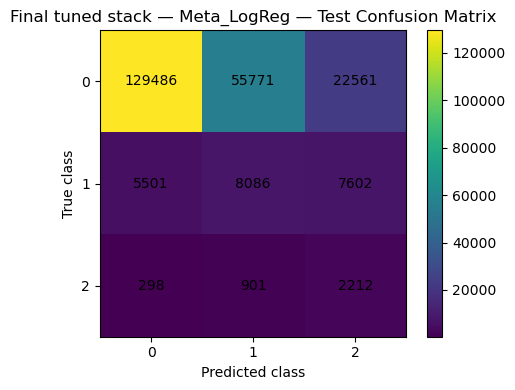

,model,importance
0,LightGBM,0.911926
1,CatBoost,0.633107
2,ExtraTrees,0.470883
3,LogReg,0.055008



Saved:
- ../models/stacking_4model_cv_summary.csv
- ../models/stacking_4model_final_results.csv
- ../models/stacking_4model_meta_importance.csv
- ../models/stacking_4model_meta_compare.csv
- ../models/stacking_4model_base_tuning.csv
- ../models/stacking_4model_dashboard_features.csv
- ../models/stacking_4model_dashboard_bundle.pkl
- ../models/stacking_4model_manifest.json


In [7]:

# ------------------------------------------------------------
# Refit tuned base learners on all development data, score final test, save outputs
# ------------------------------------------------------------
final_models = {}
test_meta_parts = []
final_rows = []
final_tuning_rows = []
final_selected_params = {}

for model_name in base_model_names:
    print(f"Final grid search on full development data for {model_name}...")
    best_params, tuning_df = tune_base_model(
        model_name=model_name,
        X_train=X_dev,
        y_train=y_dev,
        time_train=time_dev,
        n_splits=INNER_N_SPLITS,
    )
    final_selected_params[model_name] = best_params

    tuning_df = tuning_df.copy()
    tuning_df["outer_fold"] = "full_dev"
    tuning_df["selected_for_outer_fold"] = tuning_df.index == 0
    final_tuning_rows.extend(tuning_df.to_dict("records"))

    print(f"Refitting {model_name} on full development data with params: {best_params}")
    model, proba_test = fit_predict_base_model(model_name, best_params, X_dev, y_dev, X_test)

    final_models[model_name] = model
    pred_test = np.asarray(proba_test).argmax(axis=1)

    row = eval_multiclass(y_test, pred_test, proba_test, name=model_name, split="test")
    row["best_params_json"] = json.dumps(best_params, sort_keys=True)
    final_rows.append(row)
    test_meta_parts.append(np.asarray(proba_test))

X_meta_test = np.hstack(test_meta_parts)
proba_stack_test = meta_model.predict_proba(X_meta_test)
pred_stack_test = np.asarray(proba_stack_test).argmax(axis=1)

final_rows.append(
    eval_multiclass(
        y_test,
        pred_stack_test,
        proba_stack_test,
        name=f"Stacking_{best_meta_name}",
        split="test",
    )
)

final_results = (
    pd.DataFrame(final_rows)
    .sort_values(TUNING_SORT_COLUMNS, ascending=TUNING_SORT_ASC)
    .reset_index(drop=True)
)
display(final_results)

cm_stack = confusion_matrix(y_test, pred_stack_test, labels=[0, 1, 2])
plot_confusion(cm_stack, title=f"Final tuned stack — {best_meta_name} — Test Confusion Matrix")

# Meta importance:
# - Logistic meta learner: coefficient-based summary across probability features.
# - HistGB meta learner: permutation importance on the compact meta-feature matrix.
if hasattr(meta_model, "coef_"):
    coef_abs = np.abs(meta_model.coef_).mean(axis=0)
    meta_importance = (
        pd.DataFrame({"meta_feature": meta_feature_names, "importance": coef_abs})
        .assign(model=lambda d: d["meta_feature"].str.replace(r"_p[0-2]$", "", regex=True))
        .groupby("model", as_index=False)["importance"]
        .mean()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
else:
    perm = permutation_importance(
        meta_model,
        X_meta_train,
        y_meta_train,
        n_repeats=10,
        random_state=RANDOM_SEED,
        scoring="recall_macro",
    )
    meta_importance = (
        pd.DataFrame({"meta_feature": meta_feature_names, "importance": perm.importances_mean})
        .assign(model=lambda d: d["meta_feature"].str.replace(r"_p[0-2]$", "", regex=True))
        .groupby("model", as_index=False)["importance"]
        .mean()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

display(meta_importance)

# ------------------------------------------------------------
# Save compact, GitHub-clean outputs only
# ------------------------------------------------------------
base_tuning_full_df = pd.concat([
    base_tuning_df,
    pd.DataFrame(final_tuning_rows),
], ignore_index=True)

cv_summary_to_save = cv_summary.copy()
cv_summary_to_save.to_csv(OUT_CV_SUMMARY, index=False)

final_summary = final_results[
    [c for c in [
        "model",
        "split",
        "macro_recall",
        "recall_2",
        "precision_2",
        "ap_class2",
        "macro_map",
        "prob_rmse_macro",
        "best_params_json",
    ] if c in final_results.columns]
].copy()
final_summary.to_csv(OUT_FINAL_RESULTS, index=False)

meta_importance.to_csv(OUT_META_IMPORTANCE, index=False)
meta_compare_df.to_csv(OUT_META_COMPARE, index=False)
base_tuning_full_df.to_csv(OUT_BASE_TUNING, index=False)

# Dashboard feature spec helps you build Streamlit input widgets safely.
feature_spec = pd.DataFrame({
    "feature": list(X_dev.columns),
    "type": ["categorical" if c in cat_cols else "numeric" for c in X_dev.columns],
    "example_value": [X_dev[c].iloc[0] if len(X_dev) else "" for c in X_dev.columns],
})
feature_spec.to_csv(OUT_DASHBOARD_FEATURES, index=False)

# Save one compact bundle for dashboard inference.
dashboard_bundle = {
    "model_family": "stacking_4model",
    "forecast_horizon": "next_3h_block",
    "feature_columns": list(X_dev.columns),
    "categorical_features": list(cat_cols),
    "numeric_features": list(num_cols),
    "base_model_order": list(final_models.keys()),
    "base_models": final_models,
    "meta_model": meta_model,
    "winning_meta_model_name": best_meta_name,
    "meta_compare_table": meta_compare_df,
    "selected_base_params": final_selected_params,
    "class_labels": [0, 1, 2],
}
joblib.dump(dashboard_bundle, OUT_DASHBOARD_BUNDLE)

manifest = {
    "cv_summary": str(OUT_CV_SUMMARY),
    "final_summary": str(OUT_FINAL_RESULTS),
    "meta_importance": str(OUT_META_IMPORTANCE),
    "meta_compare": str(OUT_META_COMPARE),
    "base_tuning": str(OUT_BASE_TUNING),
    "dashboard_bundle": str(OUT_DASHBOARD_BUNDLE),
    "dashboard_features": str(OUT_DASHBOARD_FEATURES),
}
with open(OUT_MANIFEST, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("\nSaved:")
print("-", OUT_CV_SUMMARY)
print("-", OUT_FINAL_RESULTS)
print("-", OUT_META_IMPORTANCE)
print("-", OUT_META_COMPARE)
print("-", OUT_BASE_TUNING)
print("-", OUT_DASHBOARD_FEATURES)
print("-", OUT_DASHBOARD_BUNDLE)
print("-", OUT_MANIFEST)
